In [1]:
# ==============================================================================
# CELL 0: LIBRARY SETUP & CUSTOMER DATA CREATION
# Prepare the environment and build a synthetic B2B SaaS customer dataset.
# ==============================================================================
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn components
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, cross_val_score,
    cross_validate, GridSearchCV, RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder,
    OrdinalEncoder, TargetEncoder, PowerTransformer, PolynomialFeatures,
    KBinsDiscretizer
)
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, mutual_info_classif, f_classif, RFECV
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# Plot defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["font.size"] = 10

rng = np.random.default_rng(42)
n_customers = 3500

# Categorical customer attributes
industry_values = ["FinTech", "HealthTech", "E-Commerce", "EdTech", "Logistics", "Media"]
plan_values = ["Startup", "Growth", "Enterprise", "Custom"]
billing_values = ["Monthly", "Quarterly", "Annual", "Multi-Year"]
onboarding_values = ["Self-Serve", "Assisted", "Dedicated-CSM"]

industry = rng.choice(industry_values, n_customers, p=[.25, .20, .20, .15, .10, .10])
plan = rng.choice(plan_values, n_customers, p=[.35, .35, .20, .10])
billing = rng.choice(billing_values, n_customers, p=[.45, .15, .30, .10])
onboarding = rng.choice(onboarding_values, n_customers, p=[.40, .40, .20])

# Numeric customer activity measures
contract_value = rng.lognormal(mean=7.2, sigma=.85, size=n_customers).clip(150, 20000)
tenure = rng.exponential(scale=18, size=n_customers).clip(1, 72).astype(int)
licensed = rng.poisson(lam=20, size=n_customers).clip(2, 500)
active = (licensed * rng.uniform(.20, 1.00, size=n_customers)).astype(int)
tickets = rng.poisson(lam=2.2, size=n_customers)
bugs = rng.binomial(tickets, .35)
api_usage = rng.exponential(scale=50000, size=n_customers).clip(100, 1000000)

# Generate the churn probability from several customer-health signals
utilization = active / (licensed + 1e-5)
ticket_rate = tickets / (tenure + 1)
seat_cost = contract_value / (licensed + 1e-5)

log_odds = (
    -2.8
    + 0.00025 * contract_value
    - 0.05 * tenure
    - 2.5 * utilization
    + 0.8 * ticket_rate
    + 1.4 * bugs
    + 0.9 * (billing == "Monthly")
    - 1.6 * (billing == "Annual")
    - 2.4 * (billing == "Multi-Year")
    + 0.004 * seat_cost
)

probability = 1 / (1 + np.exp(-log_odds))
churn = (rng.random(n_customers) < probability).astype(int)

raw_df = pd.DataFrame({
    "Industry": industry,
    "Contract_Plan": plan,
    "Billing_Cycle": billing,
    "Onboarding_Tier": onboarding,
    "Monthly_Contract_Value": np.round(contract_value, 2),
    "Tenure_Months": tenure,
    "Licensed_Seats": licensed,
    "Active_Seats": active,
    "Support_Tickets": tickets,
    "Unresolved_Bugs": bugs,
    "API_Calls_Monthly": np.round(api_usage, 0),
    "Churn": churn
})

# Add a small amount of missing data for preprocessing practice
missing_onboarding = rng.choice(raw_df.index, size=75, replace=False)
missing_api = rng.choice(raw_df.index, size=50, replace=False)
raw_df.loc[missing_onboarding, "Onboarding_Tier"] = np.nan
raw_df.loc[missing_api, "API_Calls_Monthly"] = np.nan

raw_df.to_csv("enterprise_saas_churn_fe.csv", index=False)

print("Dataset created: enterprise_saas_churn_fe.csv")
print(f"Rows: {len(raw_df):,} | Churn proportion: {raw_df['Churn'].mean()*100:.2f}%")
display(raw_df.head(3))


Dataset created: enterprise_saas_churn_fe.csv
Rows: 3,500 | Churn proportion: 13.26%


,Industry,Contract_Plan,Billing_Cycle,Onboarding_Tier,Monthly_Contract_Value,Tenure_Months,Licensed_Seats,Active_Seats,Support_Tickets,Unresolved_Bugs,API_Calls_Monthly,Churn
0,EdTech,Growth,Annual,Self-Serve,549.09,4,16,9,4,1,55089.0,0
1,HealthTech,Growth,Multi-Year,Self-Serve,4338.81,19,16,7,1,1,8432.0,0
2,Logistics,Startup,Quarterly,Self-Serve,2113.89,40,25,8,1,0,102694.0,0


In [2]:
# ==============================================================================
# SECTION 1: CATEGORY REPRESENTATION & LEAKAGE CONTROL
# ==============================================================================
"""
Categorical variables need an encoding strategy that matches the model.

- Ordinal encoding is appropriate when categories have a genuine order.
- One-hot encoding represents nominal categories without inventing a ranking.
- Target encoding summarizes the target rate for each category, but it must
  be fitted without allowing validation information to leak into training.

For the demonstration below, Scikit-Learn's cross-validated TargetEncoder is
used so that the category statistics are estimated in a leakage-aware manner.
"""

# Fit target encoding for the Industry column
industry_encoder = TargetEncoder(
    cv=5,
    smooth="auto",
    random_state=42
)

industry_encoded = industry_encoder.fit_transform(
    raw_df[["Industry"]],
    raw_df["Churn"]
)

encoded_preview = pd.DataFrame({
    "Industry": raw_df["Industry"].head(5).to_numpy(),
    "Encoded_Churn_Rate": industry_encoded[:5].ravel()
})

print("--- Leakage-Controlled Industry Encoding ---")
display(encoded_preview)


--- Leakage-Controlled Industry Encoding ---


,Industry,Encoded_Churn_Rate
0,EdTech,0.129591
1,HealthTech,0.140240
2,Logistics,0.136677
3,EdTech,0.135461
4,FinTech,0.135730


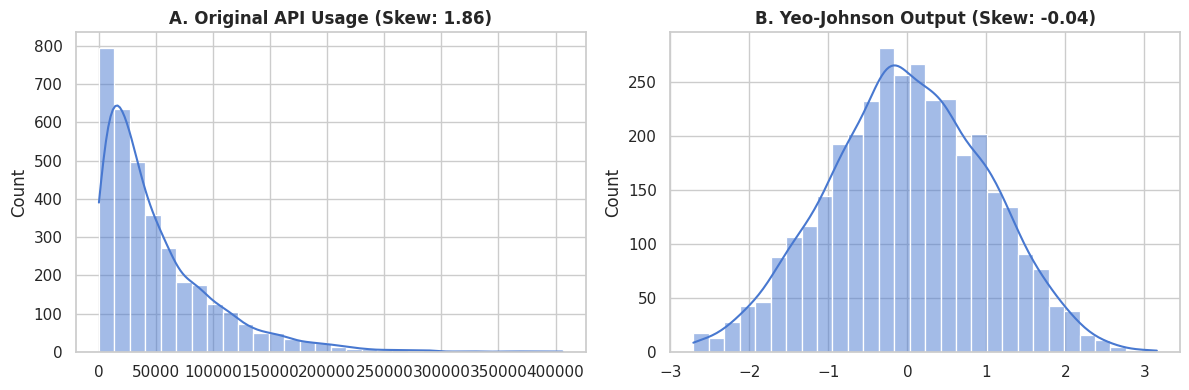

In [3]:
# ==============================================================================
# SECTION 2: DISTRIBUTION NORMALIZATION & POWER TRANSFORMATION
# ==============================================================================
"""
Strongly right-skewed variables can make some algorithms harder to train.

A power transformation can reduce the influence of very large observations
while also standardizing the resulting feature. Yeo-Johnson is convenient
because it can handle zero and negative values as well.
"""

api_values = raw_df["API_Calls_Monthly"].dropna().to_numpy().reshape(-1, 1)

yj_transformer = PowerTransformer(
    method="yeo-johnson",
    standardize=True
)
api_adjusted = yj_transformer.fit_transform(api_values)

fig, panels = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    api_values.ravel(),
    bins=30,
    kde=True,
    ax=panels[0]
)
panels[0].set_title(
    f"A. Original API Usage (Skew: {pd.Series(api_values.ravel()).skew():.2f})",
    fontweight="bold"
)

sns.histplot(
    api_adjusted.ravel(),
    bins=30,
    kde=True,
    ax=panels[1]
)
panels[1].set_title(
    f"B. Yeo-Johnson Output (Skew: {pd.Series(api_adjusted.ravel()).skew():.2f})",
    fontweight="bold"
)

plt.tight_layout()
plt.show()


In [4]:
# ==============================================================================
# SECTION 3: MUTUAL-INFORMATION FEATURE SCREENING
# ==============================================================================
"""
Feature selection can be performed before model fitting to identify variables
that carry useful predictive information.

Here, Mutual Information is used as a filter technique. Unlike a simple
correlation score, it can detect more general relationships between a feature
and the binary target.
"""

numeric_block = raw_df.select_dtypes(include="number").copy()
numeric_block = numeric_block.drop(columns="Churn").dropna()

target_block = raw_df.loc[numeric_block.index, "Churn"]

mi_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=min(5, numeric_block.shape[1])
)
mi_selector.fit(numeric_block, target_block)

ranked_features = (
    pd.Series(mi_selector.scores_, index=numeric_block.columns)
    .sort_values(ascending=False)
)

print("=== FIVE HIGHEST MUTUAL-INFORMATION FEATURES ===")
print(ranked_features.head(5).round(4))


=== FIVE HIGHEST MUTUAL-INFORMATION FEATURES ===
Unresolved_Bugs           0.0532
Support_Tickets           0.0367
Monthly_Contract_Value    0.0317
Tenure_Months             0.0163
Licensed_Seats            0.0080
dtype: float64


In [5]:
# ==============================================================================
# SECTION 4: FEATURE ENGINEERING IMPACT — BASELINE VS ENHANCED FEATURES
# ==============================================================================
# Compare a standard Random Forest pipeline with one using domain ratios.

X_all = raw_df.drop(columns="Churn")
y_all = raw_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=42
)

numeric_features = [
    "Monthly_Contract_Value",
    "Tenure_Months",
    "Licensed_Seats",
    "Active_Seats",
    "Support_Tickets",
    "Unresolved_Bugs",
    "API_Calls_Monthly"
]

categorical_features = [
    "Industry",
    "Contract_Plan",
    "Billing_Cycle",
    "Onboarding_Tier"
]

# Preprocessing for the original feature set
raw_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("fill", SimpleImputer(strategy="median")),
                ("scale", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "categorical",
            Pipeline([
                ("fill", SimpleImputer(strategy="most_frequent")),
                ("encode", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ))
            ]),
            categorical_features
        )
    ]
)

baseline_model = Pipeline([
    ("preprocess", raw_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=120,
        random_state=42,
        n_jobs=-1
    ))
])

folds = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

baseline_roc = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=folds,
    scoring="roc_auc",
    n_jobs=-1
).mean()

baseline_pr = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=folds,
    scoring="average_precision",
    n_jobs=-1
).mean()

print("=== BASELINE: ORIGINAL FEATURES ===")
print(f"Mean 5-Fold ROC-AUC: {baseline_roc:.4f}")
print(f"Mean 5-Fold PR-AUC : {baseline_pr:.4f}")


# Create reusable customer-health ratios
def add_customer_health_features(frame):
    result = frame.copy()
    result["Seat_Utilization"] = (
        result["Active_Seats"] / result["Licensed_Seats"].clip(lower=1)
    )
    result["Ticket_Velocity"] = (
        result["Support_Tickets"] / (result["Tenure_Months"] + 1)
    )
    result["Bug_Rate"] = (
        result["Unresolved_Bugs"] / (result["Support_Tickets"] + 1)
    )
    return result


X_train_enhanced = add_customer_health_features(X_train)
X_test_enhanced = add_customer_health_features(X_test)

engineered_numeric = numeric_features + [
    "Seat_Utilization",
    "Ticket_Velocity",
    "Bug_Rate"
]

enhanced_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("fill", SimpleImputer(strategy="median")),
                ("scale", StandardScaler())
            ]),
            engineered_numeric
        ),
        (
            "categorical",
            Pipeline([
                ("fill", SimpleImputer(strategy="most_frequent")),
                ("encode", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ))
            ]),
            categorical_features
        )
    ]
)

enhanced_model = Pipeline([
    ("preprocess", enhanced_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=120,
        random_state=42,
        n_jobs=-1
    ))
])

enhanced_roc = cross_val_score(
    enhanced_model,
    X_train_enhanced,
    y_train,
    cv=folds,
    scoring="roc_auc",
    n_jobs=-1
).mean()

enhanced_pr = cross_val_score(
    enhanced_model,
    X_train_enhanced,
    y_train,
    cv=folds,
    scoring="average_precision",
    n_jobs=-1
).mean()

print("\n=== ENHANCED: DOMAIN FEATURES INCLUDED ===")
print(f"Mean 5-Fold ROC-AUC: {enhanced_roc:.4f} | Gain: {(enhanced_roc-baseline_roc)*100:.2f}%")
print(f"Mean 5-Fold PR-AUC : {enhanced_pr:.4f} | Gain: {(enhanced_pr-baseline_pr)*100:.2f}%")
print("Key observation: compact domain ratios can expose customer-health signals directly.")


=== BASELINE: ORIGINAL FEATURES ===
Mean 5-Fold ROC-AUC: 0.8603
Mean 5-Fold PR-AUC : 0.5546

=== ENHANCED: DOMAIN FEATURES INCLUDED ===
Mean 5-Fold ROC-AUC: 0.8667 | Gain: 0.63%
Mean 5-Fold PR-AUC : 0.5674 | Gain: 1.28%
Key observation: compact domain ratios can expose customer-health signals directly.


In [6]:
# ==============================================================================
# SECTION 5: FINAL PRODUCTION PIPELINE — ENGINEERING, BALANCING & TUNING
# ==============================================================================
"""
The final workflow combines:
1. Three customer-domain features.
2. Missing-value treatment and categorical encoding.
3. XGBoost classification.
4. Class-imbalance compensation using scale_pos_weight.
5. Five-fold GridSearchCV over multiple hyperparameters.
6. Holdout evaluation and a before/after scorecard.
7. Persistence of the fitted pipeline with joblib.
"""

from sklearn.base import BaseEstimator, TransformerMixin

# -------------------------------------------------------------------------------
# Step 1: Custom feature transformer
# -------------------------------------------------------------------------------
class CustomerFeatureBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        data = X.copy()

        data["Seat_Utilization"] = (
            data["Active_Seats"] / data["Licensed_Seats"].clip(lower=1)
        )
        data["Ticket_Velocity"] = (
            data["Support_Tickets"] / (data["Tenure_Months"] + 1)
        )
        data["Bug_Rate"] = (
            data["Unresolved_Bugs"] / (data["Support_Tickets"] + 1)
        )

        return data


# -------------------------------------------------------------------------------
# Step 2: Preprocessing + XGBoost
# -------------------------------------------------------------------------------
production_numeric = numeric_features + [
    "Seat_Utilization",
    "Ticket_Velocity",
    "Bug_Rate"
]

production_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("standardize", StandardScaler())
            ]),
            production_numeric
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ))
            ]),
            categorical_features
        )
    ]
)

positive_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = Pipeline([
    ("feature_builder", CustomerFeatureBuilder()),
    ("preprocessor", production_preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=positive_weight,
        random_state=42,
        n_jobs=-1
    ))
])


# -------------------------------------------------------------------------------
# Step 3: Hyperparameter search
# -------------------------------------------------------------------------------
search_space = {
    "classifier__n_estimators": [100, 160],
    "classifier__max_depth": [3, 5],
    "classifier__learning_rate": [0.05, 0.10]
}

tuning_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

tuned_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=search_space,
    scoring="roc_auc",
    cv=tuning_cv,
    n_jobs=-1,
    refit=True
)

tuned_search.fit(X_train, y_train)

print("=== OPTIMAL XGBOOST SETTINGS ===")
print(tuned_search.best_params_)
print(f"Best mean CV ROC-AUC: {tuned_search.best_score_:.4f}")


# -------------------------------------------------------------------------------
# Step 4: Holdout comparison
# -------------------------------------------------------------------------------
baseline_model.fit(X_train, y_train)

baseline_probability = baseline_model.predict_proba(X_test)[:, 1]
baseline_prediction = (baseline_probability >= 0.50).astype(int)

best_pipeline = tuned_search.best_estimator_

tuned_probability = best_pipeline.predict_proba(X_test)[:, 1]
tuned_prediction = (tuned_probability >= 0.50).astype(int)

before = {
    "ROC-AUC": roc_auc_score(y_test, baseline_probability),
    "PR-AUC": average_precision_score(y_test, baseline_probability),
    "F1-Score": f1_score(y_test, baseline_prediction)
}

after = {
    "ROC-AUC": roc_auc_score(y_test, tuned_probability),
    "PR-AUC": average_precision_score(y_test, tuned_probability),
    "F1-Score": f1_score(y_test, tuned_prediction)
}

print("\n=== HOLDOUT PERFORMANCE ===")
for metric in before:
    print(f"{metric}: baseline={before[metric]:.4f} | tuned={after[metric]:.4f}")


# -------------------------------------------------------------------------------
# Step 5: Metric scorecard
# -------------------------------------------------------------------------------
comparison = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "F1-Score"],
    "Baseline_RF": [before["ROC-AUC"], before["PR-AUC"], before["F1-Score"]],
    "Tuned_XGBoost": [after["ROC-AUC"], after["PR-AUC"], after["F1-Score"]]
})

comparison["Delta"] = (
    comparison["Tuned_XGBoost"] - comparison["Baseline_RF"]
)

print("\n=== PERFORMANCE SCORECARD ===")
display(comparison.round(4))


# Save the fitted end-to-end workflow
output_file = "customer_churn_xgboost_pipeline.joblib"
joblib.dump(best_pipeline, output_file)
print(f"\nFinal pipeline saved to: {output_file}")


=== OPTIMAL XGBOOST SETTINGS ===
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best mean CV ROC-AUC: 0.8754

=== HOLDOUT PERFORMANCE ===
ROC-AUC: baseline=0.9090 | tuned=0.9186
PR-AUC: baseline=0.6853 | tuned=0.6959
F1-Score: baseline=0.4132 | tuned=0.6039

=== PERFORMANCE SCORECARD ===


,Metric,Baseline_RF,Tuned_XGBoost,Delta
0,ROC-AUC,0.9090,0.9186,0.0095
1,PR-AUC,0.6853,0.6959,0.0106
2,F1-Score,0.4132,0.6039,0.1907



Final pipeline saved to: customer_churn_xgboost_pipeline.joblib
